In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train=pd.read_csv("C:/Users/HP/Downloads/fraudTrain.csv")
test=pd.read_csv("C:/Users/HP/Downloads/fraudTest.csv")

In [3]:
print(train.shape)
print(test.shape)

(1296675, 23)
(555719, 23)


In [4]:
train

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,...,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,...,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,...,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0


In [5]:
drop_cols = [
    'Unnamed: 0',
    'first',
    'last',
    'street',
    'cc_num',
    'trans_num'
]

train = train.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)

In [6]:
train['trans_date_trans_time'] = pd.to_datetime(train['trans_date_trans_time'])
test['trans_date_trans_time'] = pd.to_datetime(test['trans_date_trans_time'])

train['hour'] = train['trans_date_trans_time'].dt.hour
train['day'] = train['trans_date_trans_time'].dt.day
train['month'] = train['trans_date_trans_time'].dt.month

test['hour'] = test['trans_date_trans_time'].dt.hour
test['day'] = test['trans_date_trans_time'].dt.day
test['month'] = test['trans_date_trans_time'].dt.month

train = train.drop(columns=['trans_date_trans_time'])
test = test.drop(columns=['trans_date_trans_time'])

In [7]:
categorical_cols = train.select_dtypes(include='object').columns
print(categorical_cols)

Index(['merchant', 'category', 'gender', 'city', 'state', 'job', 'dob'], dtype='object')


In [8]:
from sklearn.preprocessing import LabelEncoder
for col in categorical_cols:
    le = LabelEncoder()
    combined = pd.concat([train[col], test[col]]).astype(str)
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

In [9]:
X_train = train.drop('is_fraud', axis=1)
y_train = train['is_fraud']

X_test = test.drop('is_fraud', axis=1)
y_test = test['is_fraud']

In [10]:
print(y_train.value_counts())

is_fraud
0    1289169
1       7506
Name: count, dtype: int64


In [11]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [12]:
print(y_train_res.value_counts())

is_fraud
0    1289169
1    1289169
Name: count, dtype: int64


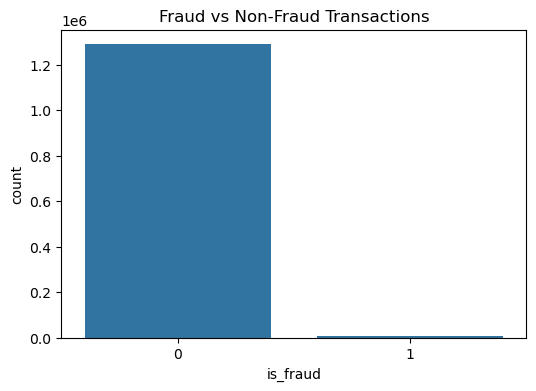

In [13]:
#Countplot (Fraud vs Non-Fraud)
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=train)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

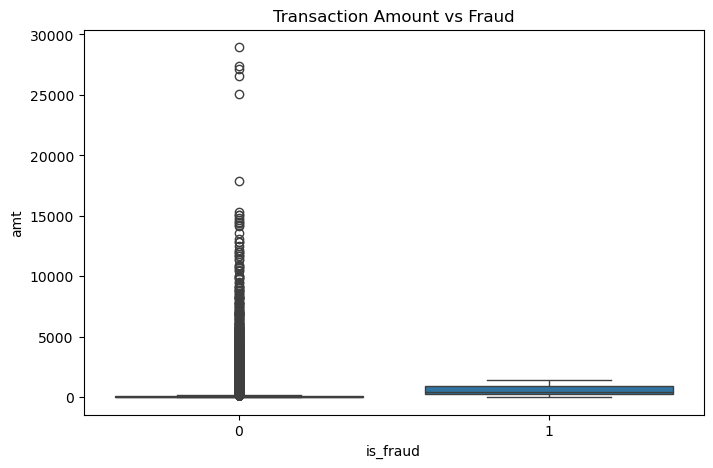

In [14]:
#Boxplot (Transaction Amount vs Fraud)
plt.figure(figsize=(8,5))
sns.boxplot(x='is_fraud', y='amt', data=train)
plt.title("Transaction Amount vs Fraud")
plt.show()

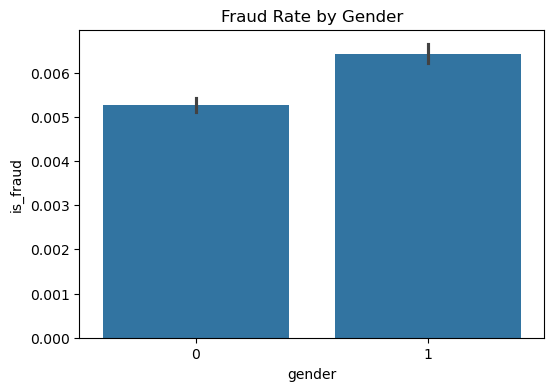

In [15]:
plt.figure(figsize=(6,4))
sns.barplot(x='gender', y='is_fraud', data=train)
plt.title("Fraud Rate by Gender")
plt.show()

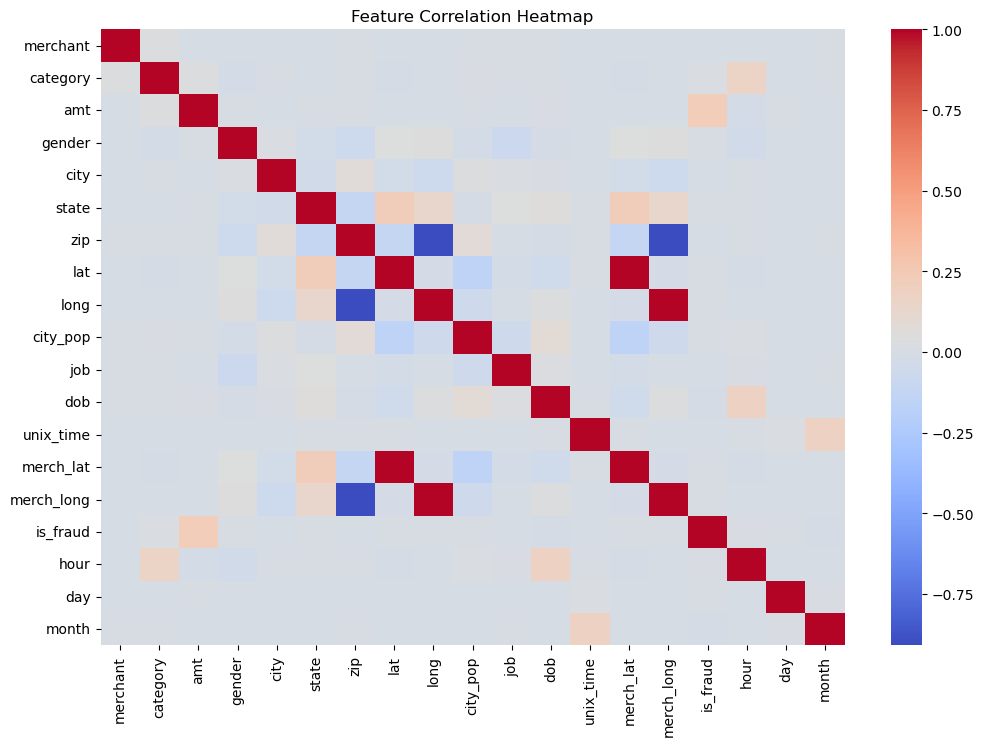

In [16]:
plt.figure(figsize=(12,8))
corr = train.corr()
sns.heatmap(corr, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

In [18]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_res, y_train_res)

LogisticRegression(max_iter=1000)

In [19]:
lr_pred = lr_model.predict(X_test)

In [20]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

print("F1 Score:", f1_score(y_test, lr_pred))

print("Classification Report:")
print(classification_report(y_test, lr_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

Logistic Regression Accuracy: 0.9576494595290066
F1 Score: 0.12008823419448911
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    553574
           1       0.07      0.75      0.12      2145

    accuracy                           0.96    555719
   macro avg       0.53      0.85      0.55    555719
weighted avg       1.00      0.96      0.97    555719

Confusion Matrix:
[[530578  22996]
 [   539   1606]]


In [21]:
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train_res, y_train_res)

DecisionTreeClassifier()

In [22]:
dt_pred = dt_model.predict(X_test)

In [23]:
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

print("F1 Score:", f1_score(y_test, dt_pred))

print("Classification Report:")
print(classification_report(y_test, dt_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

Decision Tree Accuracy: 0.9346630221388867
F1 Score: 0.07996959331052832
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97    553574
           1       0.04      0.74      0.08      2145

    accuracy                           0.93    555719
   macro avg       0.52      0.84      0.52    555719
weighted avg       1.00      0.93      0.96    555719

Confusion Matrix:
[[517832  35742]
 [   567   1578]]


In [ ]:
rf_model = RandomForestClassifier()
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

print("F1 Score:", f1_score(y_test, dt_pred))
print("Classification Report:")
print(classification_report(y_test, dt_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

rf_model.fit(X_train_res, y_train_res)

In [ ]:
rf_pred = rf_model.predict(X_test)

In [27]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("F1 Score:", f1_score(y_test, rf_pred))

print("Classification Report:")
print(classification_report(y_test, rf_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Accuracy: 0.9975077332248853
F1 Score: 0.6455080624520092
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.72      0.59      0.65      2145

    accuracy                           1.00    555719
   macro avg       0.86      0.79      0.82    555719
weighted avg       1.00      1.00      1.00    555719

Confusion Matrix:
[[553073    501]
 [   884   1261]]


In [28]:
nb_model = GaussianNB()

nb_model.fit(X_train_res, y_train_res)

GaussianNB()

In [29]:
nb_pred = nb_model.predict(X_test)

In [30]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

print("F1 Score:", f1_score(y_test, nb_pred))

print("Classification Report:")
print(classification_report(y_test, nb_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, nb_pred))

Naive Bayes Accuracy: 0.9385120897431976
F1 Score: 0.07693554487006321
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97    553574
           1       0.04      0.66      0.08      2145

    accuracy                           0.94    555719
   macro avg       0.52      0.80      0.52    555719
weighted avg       0.99      0.94      0.96    555719

Confusion Matrix:
[[520125  33449]
 [   721   1424]]


In [31]:
print("Logistic Regression:", accuracy_score(y_test, lr_pred))
print("Decision Tree:", accuracy_score(y_test, dt_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))
print("Naive Bayes:", accuracy_score(y_test, nb_pred))

Logistic Regression: 0.9576494595290066
Decision Tree: 0.9346630221388867
Random Forest: 0.9975077332248853
Naive Bayes: 0.9385120897431976
